In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error ,r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import model_selection
from sklearn.linear_model import Ridge ,Lasso,ElasticNet
import statsmodels.api as sm
from warnings import filterwarnings
filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

print("Burada kütüphaneleri tanımladık")

Burada kütüphaneleri tanımladık


In [36]:
df=pd.read_csv("forestfires.csv")
df= df.iloc[:,1:len(df)]
print("Burada veri okuma islemini gerceklestiriyoruz csv'den okunuyor ")

Burada veri okuma islemini gerceklestiriyoruz csv'den okunuyor 


In [37]:
df.head()


,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the CSV file
df = pd.read_csv("./forestfires.csv")  # Ensure the file path is correct
df = df.dropna()

# Create dummy variables for 'month' and 'day'
dms = pd.get_dummies(df[['month', 'day']])

# Define target variable
y = df["area"]

# Drop 'area', 'month', and 'day' from X
X_ = df.drop(['area', 'month', 'day'], axis=1).astype('float')

# Concatenate dummy variables with X
X = pd.concat([X_, dms], axis=1)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=99)


In [39]:
df.info()
print("Veri setinin veri tipi ve öğe sayısı")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
Veri setinin veri tipi ve öğe sayısı


In [40]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [41]:
df.isnull()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,False,False,False,False,False,False,False,False,False,False,False,False,False
513,False,False,False,False,False,False,False,False,False,False,False,False,False
514,False,False,False,False,False,False,False,False,False,False,False,False,False
515,False,False,False,False,False,False,False,False,False,False,False,False,False


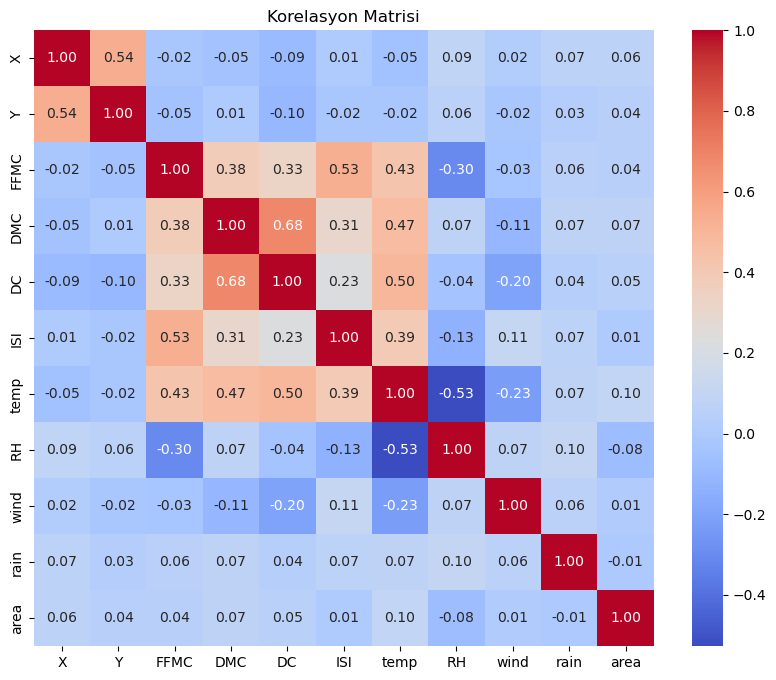

In [42]:
# Sadece sayısal sütunları seçtik
numerical_columns = df.select_dtypes(include=['float64', 'int64'])
korelasyon = numerical_columns.corr()

# Korelasyon matrisini görselleştirdik
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(korelasyon, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()


In [43]:
print(df.describe())

                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain         area  
count  517.000000  517.000000  517.000000  517.000000   517.000000  
mean    18.889168   44.288201    4.017602    0.021663    12.847292  
std      5.806625   16.317469    1.791653    0.295959    63.655

In [44]:
print(df.isnull().sum())
print("Veri setinin eksik değerleri")


X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64
Veri setinin eksik değerleri


# import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show()

In [1]:

# veri setimizin %75'ini eğitime ayırırken kalanları teste ayıroyuruz.
#random_state=123 parametresi, veri bölmesinin her çalıştırmada aynı sonucu vermesini sağlar, böylece kodun yeniden çalıştırılmasında tutarlılık sağlanır.
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.25,random_state=123)


NameError: name 'train_test_split' is not defined

In [54]:
print("Bizler KNN, RF ve ExtraTree yöntemlerini kullanıyoruz")
print("Oncelikle KNN için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi")
###########################################
#burada KNN with Grid Search
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor  
from sklearn.metrics import mean_squared_error, r2_score 
# Hiperparametre ızgarası
param_grid = {
    'n_neighbors': [5, 20, 30, 40, 50],      # Komşu sayısı
     # Mesafe metrikleri
    'p': [5,3]                           # Minkowski metriği için p değerleribiz mi verdik 1 2 yi
}

# KNN model
knn_model = KNeighborsRegressor()

# GridSearchCV
grid_search = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # Performans metriği
    cv=5,                             # 5 katlı çapraz doğrulama                     
)

grid_search.fit(X_train, y_train)
# oncelikle buraya kadar calıstırıyoruz ve elde ettigimiz parametelere yeniden calisacagiz
# En iyi parametreler
print("KNN için en iyi parametreler:", grid_search.best_params_)



Bizler KNN, RF ve ExtraTree yöntemlerini kullanıyoruz
Oncelikle KNN için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi
KNN için en iyi parametreler: {'n_neighbors': 50, 'p': 5}


In [55]:
## knn icin en iyi parametre olarak bulduklarımızı kullanacagız
print("simdi knn icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz")
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor

# KNN modelini en iyi parametrelerle oluşturuyoruz
knn = KNeighborsRegressor(n_neighbors=20, p=1)

# Eğitim verisini kullanarak modeli eğitiyoruz
knn.fit(X_train, y_train)

# Eğitim seti başarısı
y_train_pred = knn.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred),
train_r2 = r2_score(y_train, y_train_pred)
print("Eğitim MSE:", train_mse)
print("Eğitim R²:", train_r2)

# Test seti başarısı
y_pred = knn.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)


simdi knn icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz
Eğitim MSE: (4949.557310983204,)
Eğitim R²: 0.044582213291034734
Test MSE: 785.8294958576922
Test R²: -0.24026789981702779


In [49]:
print("RandomForest")


RandomForest


In [50]:
print("Oncelikle Rasgele Ormanlar Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi")
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
param_grid = [
    {'bootstrap': [False,True], 'n_estimators': [3, 10], 'max_features': [1, 2, 3]},
  ]

forest_reg = RandomForestRegressor(random_state=123)
rfr_grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
rfr_grid_search.fit(X_train,y_train)

print("Random Forests için en iyi parametreler:", rfr_grid_search.best_params_)


Oncelikle Rasgele Ormanlar Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi
Random Forests için en iyi parametreler: {'bootstrap': False, 'max_features': 1, 'n_estimators': 10}


In [51]:
## simdi RFR icin en iyi paraemtrelerle testlerimizi yapıyoruz 
print("simdi RFR icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz")
from sklearn.metrics import mean_squared_error, r2_score


# rfr modelini en iyi parametrelerle oluşturuyoruz
rfr = RandomForestRegressor(bootstrap=True, max_features=1, n_estimators=10)

# Eğitim verisini kullanarak modeli eğitiyoruz
rfr.fit(X_train, y_train)

# Eğitim seti başarısı
y_train_pred = rfr.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred),
train_r2 = r2_score(y_train, y_train_pred)
print("Eğitim MSE:", train_mse)
print("Eğitim R²:", train_r2)

# Test seti başarısı
y_pred = rfr.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)

simdi RFR icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz
Eğitim MSE: (1692.5448265654147,)
Eğitim R²: 0.6732864515954837
Test MSE: 920.4160514326153
Test R²: -0.4526846969802969


In [52]:
print("Oncelikle ExtraTree Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi")
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
param_grid = [
    {'n_estimators': [10,100], 'max_features': [1, 2, 3]},
 ]

ext_reg = ExtraTreesRegressor(random_state=123)
ext_grid_search = GridSearchCV(ext_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
ext_grid_search.fit(X_train,y_train)

print("Exttra Tree  için en iyi parametreler:", ext_grid_search.best_params_)

Oncelikle ExtraTree Regresyonu için en iyi paremetreleri arıyoruz. CV=5 ve Grid Search ile parametre eniyilemesi
Exttra Tree  için en iyi parametreler: {'max_features': 3, 'n_estimators': 10}


In [53]:
## simdi Ext Tree icin en iyi paraemtrelerle testlerimizi yapıyoruz 

print("simdi Extra icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz")
from sklearn.metrics import mean_squared_error, r2_score
# ext modelini en iyi parametrelerle o=luşturuyoruz0
ext = ExtraTreesRegressor(max_features=2, n_estimators=100)

# Eğitim verisini kullanarak modeli eğitiyoruz
ext.fit(X_train, y_train)

# Eğitim seti başarısı
y_train_pred = ext.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred),
train_r2 = r2_score(y_train, y_train_pred)
print("Eğitim MSE:", train_mse)
print("Eğitim R²:", train_r2)

# Test seti başarısı
y_pred = ext.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
print("Test MSE:", test_mse)
print("Test R²:", test_r2)

simdi Extra icin buldugumuz en iyi parametrelerle, eğitim ve test basarımızı MSE ve r2 uzerınden hesaplıyoruz
Eğitim MSE: (0.414942057260982,)
Eğitim R²: 0.9999199033373993
Test MSE: 976.6903512722498
Test R²: -0.5415019379259289
